In [1]:
import torch
words = open('../names.txt', 'r').read().splitlines()

In [2]:
N = torch.zeros((27, 27), dtype = torch.int32)
chars = sorted(list(set(''.join(words)))) # 把 words 这个字符串列表里的所有单词，拼接成一个大字符串，中间不加任何东西。
stoi = {s:i+1 for i,s in enumerate(chars)}  # stoi = string to integer
stoi['.'] = 0
itos = {i:s for s, i in stoi.items()}

In [16]:
# creat the training set of bigrams (x, y)
xs , ys = [], []  #  输入字符 和 希望输出字符 的标签
# 这其实是标准的监督式学习

for w in words[:1]:
    chs = ['.'] + list(w) + ['.'] 
    for ch1, ch2 in zip(chs, chs[1:]): 
        ix1 = stoi[ch1]
        ix2 = stoi[ch2]
        print(ch1, ch2)
        xs.append(ix1)
        ys.append(ix2)

# xs 和 ys 在后续用作索引，而很多索引操作要求整数
xs = torch.tensor(xs)  # 数据类型：tensor--int64，Tensor--float32
ys = torch.tensor(ys)

. e
e m
m m
m a
a .


In [26]:
print(xs, ys)

tensor([ 0,  5, 13, 13,  1]) tensor([ 5, 13, 13,  1,  0])


In [25]:
import torch.nn.functional as F
# one-hot 的规则就是：一个向量里只有一个位置是 1，其余位置全部是 0；1 所在的位置表示类别编号。

xenc = F.one_hot(xs, num_classes = 27).float()  # 列表中1的位置代表 xs 和 ys 对应的数字
xenc
# 这就是神经网络真正可以拿来做矩阵乘法的输入形式


tensor([[1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
         0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
         0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0.,
         0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0.,
         0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
         0., 0., 0., 0., 0., 0., 0., 0., 0.]])

In [27]:
xenc.shape

torch.Size([5, 27])

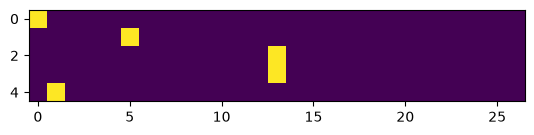

In [28]:
import matplotlib.pyplot as plt
%matplotlib inline

plt.imshow(xenc)

In [29]:
# 神经网络里的核心计算，本质上几乎都是: 连续数值的加减乘除 + 梯度更新
# 整数不适合表达这种连续变化
# 所以我们希望 xenc.dtype 是浮点数
xenc.dtype


torch.float32

In [39]:
# 随机生成一个 27 × 27 的浮点权重矩阵，作为神经网络参数 W 的初始值

W = torch.randn((27,27))  # randn 生成的是服从标准正态分布的随机浮点数。
xenc @ W  # 矩阵乘法，就是“左边的行”去和“右边的列”做点积。

tensor([[ 0.2293, -0.8688, -0.3457, -0.5350,  1.6736,  0.4095, -0.7548,  0.3728,
         -0.6944,  1.5585,  1.5701,  0.7538,  0.0150, -0.2837,  0.3930,  1.5612,
          0.1763,  0.5931,  0.7980,  0.0767,  0.0827, -1.2943,  0.6101,  0.1624,
          1.3497,  1.1663,  1.2355],
        [-0.1323,  0.5733,  0.3912,  0.7374,  0.8830, -0.1631, -0.9620,  0.3411,
          0.1577,  0.4843,  1.8341, -1.9354,  2.3962, -0.5273, -0.7480, -2.2348,
         -0.5519, -0.4414, -0.4789,  0.5054,  0.0793, -0.2875,  0.7379, -0.6611,
          0.4498, -1.1216,  0.1952],
        [-0.0335,  0.5182,  1.6516,  0.4746,  1.2605, -2.3818,  0.0912,  0.0145,
          0.5539,  0.6386,  0.8284, -0.1591,  0.8738, -0.7031,  1.4081,  0.6540,
         -1.1511,  1.0116,  0.5926,  0.9506, -0.2565, -2.4272, -1.0594,  2.4229,
          1.5284, -1.0184, -1.2099],
        [-0.0335,  0.5182,  1.6516,  0.4746,  1.2605, -2.3818,  0.0912,  0.0145,
          0.5539,  0.6386,  0.8284, -0.1591,  0.8738, -0.7031,  1.4081,  0.6540

In [40]:
# 矩阵乘法演算 
print(xenc[0, :])
print(W[:, 0])
print(xenc[0, :] @ W[:, 0])
print((xenc @ W)[0, 0])

tensor([1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0.])
tensor([ 0.2293,  1.7195, -0.7745, -0.7050,  0.6384, -0.1323, -1.6416, -0.4053,
         0.2478,  0.8133, -0.0209,  0.2059,  1.3139, -0.0335, -0.1943, -1.0627,
         0.8643,  0.9778, -0.1496, -0.3174,  0.1215,  2.0082, -0.8261, -2.2277,
         0.7642, -0.5349, -1.5076])
tensor(0.2293)
tensor(0.2293)


In [41]:
logits = xenc @ W  # log-conuts
counts = logits.exp()  # equivalent N
probs = counts / counts.sum(1, keepdim = True)
probs

tensor([[0.0237, 0.0079, 0.0133, 0.0110, 0.1004, 0.0284, 0.0089, 0.0273, 0.0094,
         0.0895, 0.0905, 0.0400, 0.0191, 0.0142, 0.0279, 0.0897, 0.0225, 0.0341,
         0.0418, 0.0203, 0.0205, 0.0052, 0.0347, 0.0221, 0.0726, 0.0604, 0.0648],
        [0.0201, 0.0406, 0.0339, 0.0479, 0.0554, 0.0195, 0.0087, 0.0322, 0.0268,
         0.0372, 0.1433, 0.0033, 0.2514, 0.0135, 0.0108, 0.0025, 0.0132, 0.0147,
         0.0142, 0.0380, 0.0248, 0.0172, 0.0479, 0.0118, 0.0359, 0.0075, 0.0278],
        [0.0172, 0.0299, 0.0930, 0.0287, 0.0629, 0.0016, 0.0195, 0.0181, 0.0310,
         0.0338, 0.0408, 0.0152, 0.0427, 0.0088, 0.0729, 0.0343, 0.0056, 0.0490,
         0.0322, 0.0461, 0.0138, 0.0016, 0.0062, 0.2011, 0.0822, 0.0064, 0.0053],
        [0.0172, 0.0299, 0.0930, 0.0287, 0.0629, 0.0016, 0.0195, 0.0181, 0.0310,
         0.0338, 0.0408, 0.0152, 0.0427, 0.0088, 0.0729, 0.0343, 0.0056, 0.0490,
         0.0322, 0.0461, 0.0138, 0.0016, 0.0062, 0.2011, 0.0822, 0.0064, 0.0053],
        [0.0888, 0.0941,

In [42]:
probs[0, :].sum()

tensor(1.)